In [1]:
!pip install pandas matplotlib seaborn numpy

In [2]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# LOADING THE DATA
data = pd.read_csv('online_retail.csv')
print(data)
print("Data loaded successfully.")

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

                InvoiceDate  UnitPrice  CustomerID         Country  
0     

In [4]:
# DATA DESCRIPTION
print("Data Shape:")
print(data.shape)

print("First 5 rows of the data:")
print(data.head())

print("Data Description:")
print(data.describe())

print("Data Information:")
print(data.info())

print("Missing Values:")
print(data.isna().sum())  # Checking for missing values in the dataset

print("Duplicate Values:")
print(data.duplicated().sum())  # Checking for duplicate values in the dataset

Data Shape:
(541909, 8)
First 5 rows of the data:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Data Description:
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9

In [5]:
# DATA CLEANING AND TRANSFORMING
data['CustomerID'] = data['CustomerID'].fillna('Unknown')  # Handling missing customer IDs

data = data[data['UnitPrice'] > 0]  # Removing invalid unit prices

data['TransactionType'] = data['Quantity'].apply(  # Creating 'TransactionType' column to differentiate between sales and returns
    lambda x: 'Return' if x < 0 else 'Sale'
)

data['Revenue'] = data['Quantity'] * data['UnitPrice']  #Creating 'Revenue' column from 'Quantity' and 'UnitPrice'

In [6]:
# TOP PRODUCTS BY REVENUE
top_products = data.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64


In [7]:
# COUNTRY-WISE REVENUE
country_sales = data.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print(country_sales.head(10))

Country
United Kingdom    8209930.484
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64


In [8]:
# MONTHLY SALES TREND
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['MonthYear'] = data['InvoiceDate'].dt.to_period('M')
monthly_sales = data.groupby('MonthYear')['Revenue'].sum()
print(monthly_sales)

MonthYear
2010-12     748957.020
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     704804.630
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433668.010
Freq: M, Name: Revenue, dtype: float64


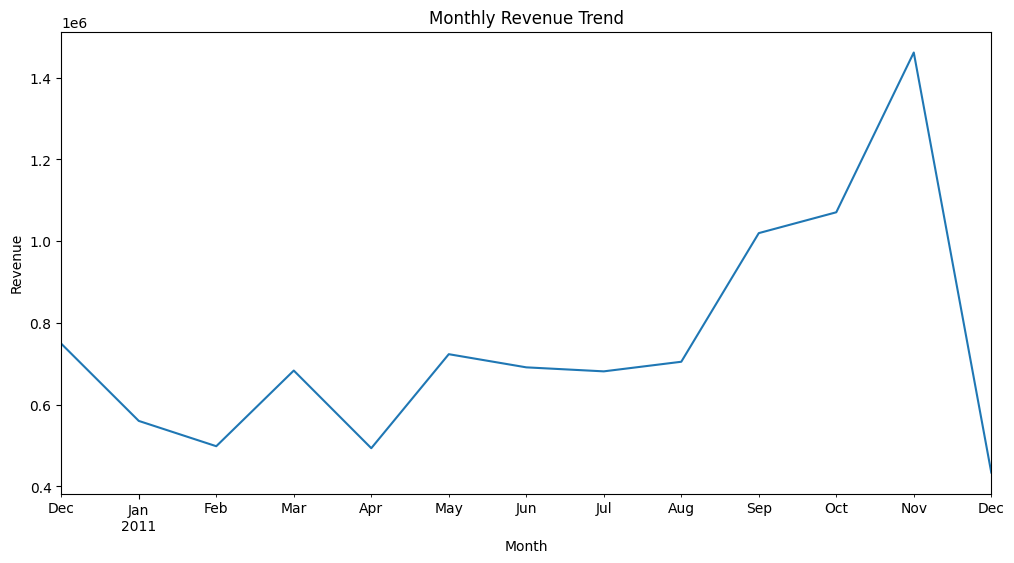

In [9]:
# MONTHLY TREND REVENUE VISUALIZATION
monthly_sales.plot(figsize=(12,6))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

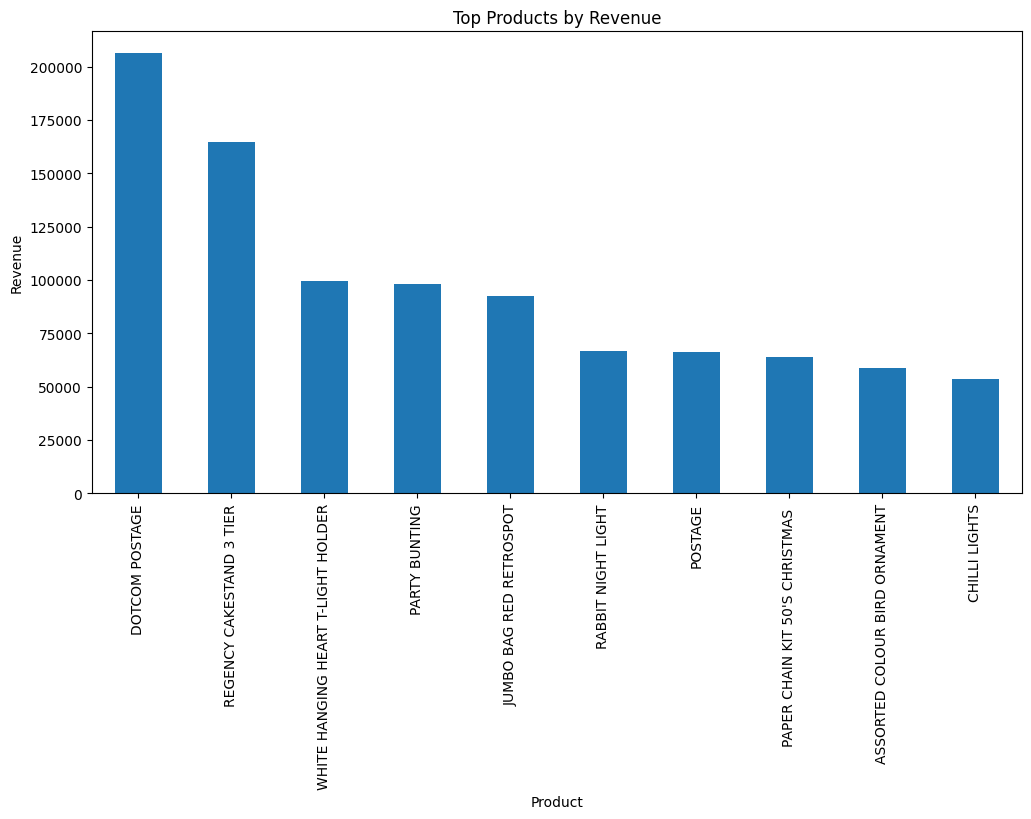

In [10]:
# TOP PRODUCTS CHART
top_products.plot(kind='bar', figsize=(12,6))
plt.title('Top Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

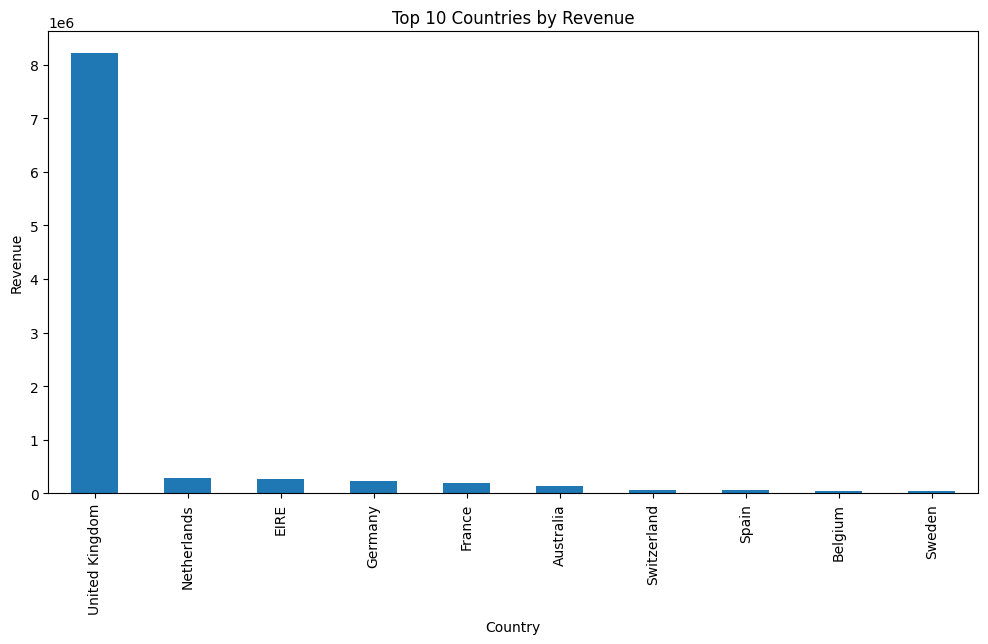

In [11]:
# COUNTRY-WISE REVENUE CHART
country_sales.head(10).plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.show()

In [12]:
!pip install prophet

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


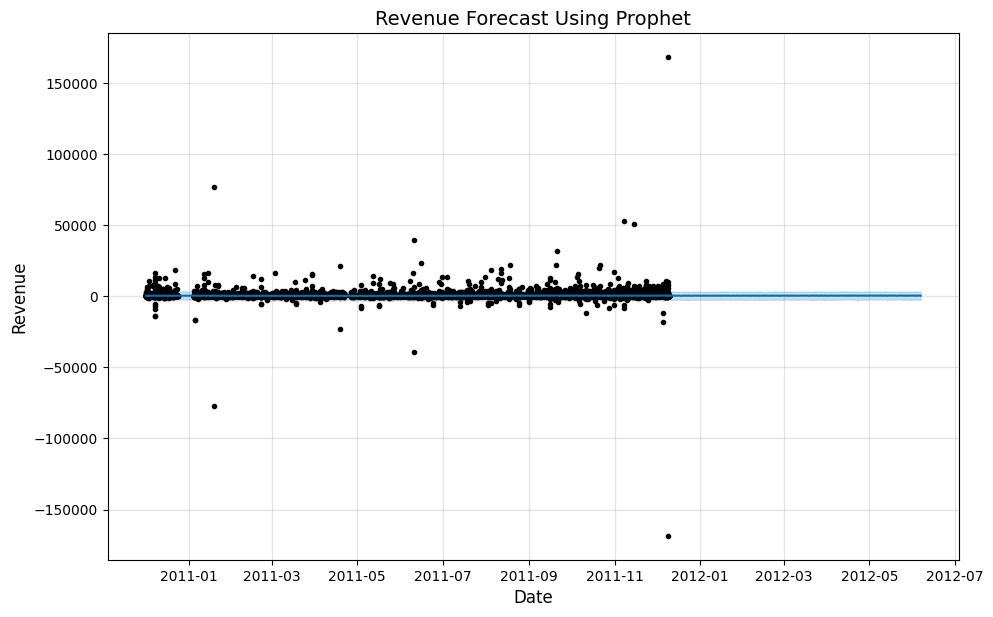

In [16]:
# Forecasting future revenue using Prophet time series model
from prophet import Prophet
import matplotlib.pyplot as plt
df = data.groupby('InvoiceDate')['Revenue'].sum().reset_index()
df.columns = ['ds', 'y']
model = Prophet()
model.fit(df)
future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.title("Revenue Forecast Using Prophet", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.grid(True)
plt.show()